# 🌡️🔥 Land Surface Temperature (LST) Analysis Pipeline — GPU Accelerated
## Step 3: LST Day/Night Analysis — India (2000–2022)
### Reference: Biswas et al. (2025) & Uthappa et al. (2025)

**Extends:** MODIS Collection 6.1 LST (MOD11A2) → Day/Night thermal metrics
**Data:** MOD11A2.061, 8-day 1km, NASA AppEEARS — **GeoTIFF** (`LST_DAY_NIGHT_INDIA_DATA/`), not HDF
**Study period:** 1 Nov 2000 – 15 Dec 2022 — **matches Step 1 (fire) & Step 2 (NDVI) exactly**

---
### What this step delivers

| # | Metric | Basis | Notes |
|---|--------|-------|-------|
| 1 | QA-filtered LST Day | LST_Day_1km + QC_Day | Keeps Good/Marginal reliability only |
| 2 | QA-filtered LST Night | LST_Night_1km + QC_Night | Keeps Good/Marginal reliability only |
| 3 | Diurnal Temperature Range (DTR) | Day − Night, monthly | Reflects atmospheric/vegetation control |
| 4 | Climatological LST mean | Seasonal baseline, 2001–2020 | Per-pixel, per-calendar-month baseline |
| 5 | LST Day anomaly | δ_day = LST_day − μ_day | Deviation from climatology, monthly |
| 6 | LST Night anomaly | δ_night = LST_night − μ_night | Deviation from climatology, monthly |
| 7 | DTR anomaly | δ_dtr = DTR − μ_dtr | Diurnal range deviation, monthly |
| 8 | LST trend (Day/Night/DTR) | Mann-Kendall τ, GPU-tiled | Computed at NDVI-aligned monthly resolution |
| 9 | Fire coincidence (thermal footprint) | Rasterized Step 1 points → LST grid | Day/Night split, exact affine transform |
| 10 | NDVI-grid reprojection | `rasterio.warp.reproject` | LST features resampled onto the NDVI pipeline's own grid |

### Design approach

- **Streaming, memory-safe:** the real archive is ~1,014 8-day composites at 
  3,781×3,536 px — a dense (T, H, W) stack would be 50+ GB *per band*, too large to hold 
  safely in memory even on a large workstation. This notebook streams each composite 
  once, accumulating running sums/counts for the climatology and the monthly aggregates, 
  and never materializes the full 8-day cube. Only the much smaller **monthly-resolution** 
  arrays (~266 months) are kept for trend analysis, mapping, and export.
- **GPU-accelerated where it matters:** CuPy runs a row-tiled (memory-bounded) 
  Mann-Kendall trend test on the monthly arrays — auto-fallback to CPU (NumPy) if no 
  CUDA device is found.
- **Same shapefile:** Uses `India_State_Boundary.shp` (dissolved), **not** 
  `India_Country_Boundary.shp`, to avoid degenerate slivers.
- **Same period:** Nov 2000 – Dec 2022 (matches fire & NDVI exactly).
- **Exact point-in-polygon clipping:** LST pixels outside India's polygon are rasterized 
  and masked out using the GeoTIFF's own affine transform, not a bounding-box filter.
- **Exact fire-point rasterization:** fire lat/lon are converted to LST grid row/col 
  using the real affine transform read from the GeoTIFFs.
- **NDVI-grid alignment:** key monthly LST features are reprojected onto the NDVI 
  pipeline's exact pixel grid and exported as GeoTIFFs, so they can be stacked 
  pixel-for-pixel with the NDVI feature rasters for a joint fire-risk model.

---

## 📦 Step 0 — Install Required Libraries

Run once. `cupy-cuda12x` + the NVIDIA JIT-header packages enable GPU acceleration.
If CuPy fails to install/import, the pipeline automatically falls back to CPU (NumPy) — 
still correct, just slower.

In [1]:
import subprocess, sys

packages = [
    "geopandas",
    "numpy",
    "pandas",
    "matplotlib",
    "tqdm",
    "rasterio",
    "pyogrio",
    # GPU acceleration (native Windows -- no WSL required)
    "cupy-cuda12x",
    "nvidia-cuda-runtime-cu12",
    "nvidia-cuda-nvrtc-cu12",
    "nvidia-cuda-nvcc-cu12",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")

Library installation complete.


## 📚 Step 1 — Imports & GPU Detection

Same auto-detect / auto-fallback pattern as the Step 1 fire-extraction and Step 2 NDVI 
notebooks.

In [2]:
import os
import re
import time
import gc
import io
import contextlib
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")

# GPU detection (CuPy) -- falls back cleanly to NumPy if unavailable
GPU_AVAILABLE = False
gpu_name = "N/A"
try:
    # CuPy's first array op probes an optional cupyx.scipy.sparse integration that this
    # environment's scipy build doesn't support under NumPy 2 -- harmless (we never touch
    # cupyx.scipy), but it both writes a wall of text to stderr AND gets displayed as
    # Jupyter "error" outputs (some internal code explicitly calls the IPython shell's
    # traceback display). Suppress both channels for just this one-time warm-up; real GPU
    # failures still raise a normal exception and are caught by the except clause below.
    from IPython.core.interactiveshell import InteractiveShell
    _orig_showtraceback = InteractiveShell.showtraceback
    InteractiveShell.showtraceback = lambda *a, **k: None
    try:
        with contextlib.redirect_stderr(io.StringIO()):
            import cupy as cp
            _test = cp.array([1, 2, 3]) * 2      # forces JIT compile now, not mid-pipeline
            _ = cp.isin(_test, cp.array([2]))
    finally:
        InteractiveShell.showtraceback = _orig_showtraceback
    GPU_AVAILABLE = True
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    print("GPU acceleration ON")
    print(f"   Device : {gpu_name}")
    print(f"   VRAM   : {free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
except Exception as e:
    import numpy as cp   # alias so downstream code (cp.xxx) works unchanged on CPU
    print(f"GPU unavailable ({e})")
    print("   Falling back to CPU (NumPy). Pipeline will still run correctly, just slower.")

def to_host(arr):
    # Bring a cp array back to a plain NumPy array (no-op on CPU fallback)
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr

print("\nAll libraries imported successfully!")

GPU acceleration ON
   Device : NVIDIA RTX PRO 4500 Blackwell
   VRAM   : 32.8 GB free / 34.2 GB total

All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  CONFIGURE PATHS — all local to this project folder
# ═══════════════════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
LST_ANALYSIS_DIR = os.path.join(BASE_DIR, "LST_analysis")

# LST data (MODIS MOD11A2.061 -- 8-day, 1km, GeoTIFF from NASA AppEEARS) -- already downloaded
LST_DIR = os.path.join(LST_ANALYSIS_DIR, "LST_DAY_NIGHT_INDIA_DATA")

# Step 1 fire points output (for thermal footprint & coincidence analysis)
FIRE_CSV_PATH = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                              "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")

# India boundary (dissolved State boundary, not Country boundary -- avoids slivers)
BOUNDARY_SHP = os.path.join(LST_ANALYSIS_DIR, "India_State_Boundary.shp")

# NDVI grid reference (MOD13A3.061, monthly, 1km) -- used to reproject LST features onto
# the exact same pixel grid as the NDVI pipeline, so the two feature sets can be stacked
# pixel-for-pixel.
NDVI_RAW_DIR = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_", "NDVI TIF File_INDIA")

OUTPUT_DIR = os.path.join(LST_ANALYSIS_DIR, "LST_Outputs")
NDVI_ALIGNED_DIR = os.path.join(OUTPUT_DIR, "NDVI_Aligned_GeoTIFFs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(NDVI_ALIGNED_DIR, exist_ok=True)

# Study period -- matches the Step 1 fire archive and the NDVI pipeline exactly
# (the fire CSV spans 2000-11-01 to 2022-12-15; the NDVI pipeline uses the same window)
STUDY_START_DATE = pd.Timestamp("2000-11-01")
STUDY_END_DATE = pd.Timestamp("2022-12-15")
CLIMATOLOGY_START = pd.Timestamp("2001-01-01")
CLIMATOLOGY_END = pd.Timestamp("2020-12-31")

# QC_Day/QC_Night mandatory QA flag (bits 0-1): 0=good, 1=produced-other-quality (kept),
# 2/3=not produced (dropped). See MOD11A2-061-QC-Day-lookup.csv in LST_DIR.
QA_THRESHOLD = 1

print("Configuration loaded:")
print(f"   LST data      : {LST_DIR}  (exists: {os.path.isdir(LST_DIR)})")
print(f"   Fire archive  : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   Boundary      : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   NDVI grid ref : {NDVI_RAW_DIR}  (exists: {os.path.isdir(NDVI_RAW_DIR)})")
print(f"   Outputs       : {OUTPUT_DIR}")
print(f"   Study period  : {STUDY_START_DATE.date()} to {STUDY_END_DATE.date()}")
print(f"   Climatology   : {CLIMATOLOGY_START.date()} to {CLIMATOLOGY_END.date()}")

Configuration loaded:
   LST data      : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_DAY_NIGHT_INDIA_DATA  (exists: True)
   Fire archive  : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Boundary      : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   NDVI grid ref : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI TIF File_INDIA  (exists: True)
   Outputs       : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs
   Study period  : 2000-11-01 to 2022-12-15
   Climatology   : 2001-01-01 to 2020-12-31


## 📍 Step 3 — Load India Boundary

Same boundary as Step 1 (forest fire extraction) and Step 2 (NDVI). Dissolves state 
polygons into a single national boundary, later rasterized onto the LST grid (Step 6) 
for exact point-in-polygon clipping.

In [4]:
print("Loading India boundary...")
india_boundary = gpd.read_file(BOUNDARY_SHP)
print(f"   Loaded {len(india_boundary)} polygons")

# This shapefile ships without a .prj (india_boundary.crs is None), but its raw
# coordinates are in Web Mercator meters (easting/northing in the millions), not
# lon/lat -- confirmed by reprojecting and checking against India's known extent
# (~68-97 deg E, ~6-37 deg N). Label the true source CRS, then reproject to EPSG:4326
# so it lines up with the LST GeoTIFFs' own CRS for rasterization.
if india_boundary.crs is None:
    india_boundary = india_boundary.set_crs("EPSG:3857", allow_override=True)
india_boundary = india_boundary.to_crs("EPSG:4326")

# Dissolve to single national boundary
india_geom = india_boundary.dissolve(by=None).geometry.iloc[0]
print(f"   Dissolved to national boundary")
print(f"   Bounds: lon=[{india_geom.bounds[0]:.2f}, {india_geom.bounds[2]:.2f}], "
      f"lat=[{india_geom.bounds[1]:.2f}, {india_geom.bounds[3]:.2f}]")

india_gdf = gpd.GeoDataFrame(geometry=[india_geom], crs="EPSG:4326")
print(f"\nIndia boundary ready")

Loading India boundary...


   Loaded 37 polygons


   Dissolved to national boundary
   Bounds: lon=[68.12, 97.41], lat=[6.75, 37.10]

India boundary ready


## 📂 Step 4 — Discover LST GeoTIFFs

The AppEEARS export splits each 8-day composite into four single-band GeoTIFFs: 
`LST_Day_1km`, `LST_Night_1km`, `QC_Day`, `QC_Night`. Scans `LST_DIR`, parses the 
acquisition date from each filename, and keeps only dates where all four bands are 
present (a handful of dates are missing one band in the raw archive).

In [5]:
print("Scanning for LST GeoTIFF data...")

BAND_TAGS = {
    'lst_day': 'LST_Day_1km',
    'lst_night': 'LST_Night_1km',
    'qc_day': 'QC_Day',
    'qc_night': 'QC_Night',
}

date_re = re.compile(r"_(\d{8})T\d{6}_aid0001\.tif$")

band_files = {band: {} for band in BAND_TAGS}
for band, tag in BAND_TAGS.items():
    for fp in Path(LST_DIR).glob(f"MOD11A2.061_{tag}_*_aid0001.tif"):
        m = date_re.search(fp.name)
        if m:
            band_files[band][m.group(1)] = fp

counts = {band: len(files) for band, files in band_files.items()}
print(f"   Files found per band: {counts}")

# Keep only dates where all four bands are present
common_dates = set.intersection(*(set(d.keys()) for d in band_files.values()))
print(f"   Dates with all 4 bands present: {len(common_dates)}")

data_index = []
for date_str in sorted(common_dates):
    acq_date = pd.Timestamp(date_str)
    data_index.append({
        'date': acq_date,
        'year': acq_date.year,
        'month': acq_date.month,
        'day_file': band_files['lst_day'][date_str],
        'night_file': band_files['lst_night'][date_str],
        'qcday_file': band_files['qc_day'][date_str],
        'qcnight_file': band_files['qc_night'][date_str],
    })

df_index = pd.DataFrame(data_index).sort_values('date').reset_index(drop=True)
print(f"\nDate range available: {df_index['date'].min().date()} to {df_index['date'].max().date()}")
print(f"Total 8-day acquisition periods: {len(df_index)}")

df_study = df_index[(df_index['date'] >= STUDY_START_DATE) & (df_index['date'] <= STUDY_END_DATE)].reset_index(drop=True)
print(f"Within study period ({STUDY_START_DATE.date()} to {STUDY_END_DATE.date()}): {len(df_study)} composites")

if len(df_study) == 0:
    print("WARNING: No LST data found in the study period!")

Scanning for LST GeoTIFF data...
   Files found per band: {'lst_day': 1015, 'lst_night': 1014, 'qc_day': 1016, 'qc_night': 1016}
   Dates with all 4 bands present: 1014

Date range available: 2000-10-31 to 2022-12-11
Total 8-day acquisition periods: 1014
Within study period (2000-11-01 to 2022-12-15): 1013 composites


## 🔧 Step 5 — GeoTIFF to Array Pipeline

Helper functions to read a single 8-day composite's four bands via `rasterio`, convert 
DN → °C, and apply the QC mandatory-QA mask (bits 0-1 ≤ `QA_THRESHOLD`, per 
`MOD11A2-061-QC-Day-lookup.csv`).

In [6]:
def read_band(path):
    """Read band 1 of a single-band GeoTIFF, returning the array + its georeferencing."""
    with rasterio.open(path) as src:
        arr = src.read(1)
        transform = src.transform
        crs = src.crs
        profile = src.profile.copy()
    return arr, transform, crs, profile


def extract_lst_data(day_path, night_path, qcday_path, qcnight_path, qa_threshold=QA_THRESHOLD):
    """
    Extract QA-filtered LST day/night (in degC) from one 8-day composite's four GeoTIFF bands.

    MOD11A2 scale: DN * 0.02 K, DN == 0 is fill/no-data.
    QC bits 0-1 (mandatory QA flag): 0=good, 1=produced-other-quality (kept),
    2/3=not produced (dropped) -- see MOD11A2-061-QC-Day-lookup.csv in LST_DIR.

    Returns a dict with lst_day, lst_night as (H, W) float32 arrays in degC (NaN where
    invalid or masked out).
    """
    lst_day_raw, transform, crs, profile = read_band(day_path)
    lst_night_raw, _, _, _ = read_band(night_path)
    qc_day, _, _, _ = read_band(qcday_path)
    qc_night, _, _, _ = read_band(qcnight_path)

    lst_day_c = np.where(lst_day_raw > 0, lst_day_raw.astype(np.float32) * 0.02 - 273.15, np.nan).astype(np.float32)
    lst_night_c = np.where(lst_night_raw > 0, lst_night_raw.astype(np.float32) * 0.02 - 273.15, np.nan).astype(np.float32)

    qa_day = qc_day & 0x03
    qa_night = qc_night & 0x03
    mask_day = qa_day <= qa_threshold
    mask_night = qa_night <= qa_threshold

    lst_day_c = np.where(mask_day, lst_day_c, np.nan).astype(np.float32)
    lst_night_c = np.where(mask_night, lst_night_c, np.nan).astype(np.float32)

    return {
        'lst_day': lst_day_c,
        'lst_night': lst_night_c,
        'transform': transform,
        'crs': crs,
        'profile': profile,
    }

print("GeoTIFF extraction pipeline ready")

GeoTIFF extraction pipeline ready


## 📊 Step 6 — Streaming Spatiotemporal Aggregation (Climatology + Monthly Means)

The real archive is **1,014 8-day composites** at 3,781×3,536 px — a dense (T, H, W) 
stack would be 50+ GB *per band*, too large to hold safely in memory. Instead this cell 
streams through the composites once in chronological order, and for every 8-day frame:

- clips it to the India boundary (using the mask rasterized from Step 3's geometry),
- folds it into a running **national 8-day time series** (one scalar per date),
- folds it into a running per-(calendar-month) sum/count for the **2001–2020 climatology**,
- folds it into a running per-(year, month) sum/count for the **monthly-aggregated series** 
  that matches the NDVI pipeline's own monthly cadence.

Only the derived monthly arrays (~266 months) are kept afterwards — each raw 8-day frame 
is discarded immediately after being folded into the running sums, so peak memory stays 
bounded regardless of how many composites are processed.

In [7]:
if len(df_study) == 0:
    print("Cannot proceed: no LST data for study period.")
else:
    print(f"Streaming {len(df_study)} LST composites (single pass: national series, "
          f"climatology, NDVI-aligned monthly aggregation)...")
    t0 = time.time()

    # Georeferencing + shape come straight from the GeoTIFFs (cheap header-only read)
    with rasterio.open(df_study.iloc[0]['day_file']) as src0:
        transform_ref = src0.transform
        crs_ref = src0.crs
        profile_ref = src0.profile.copy()
        H, W = src0.height, src0.width

    # Exact point-in-polygon India mask, rasterized onto the LST grid
    india_mask = rasterize(
        [(india_geom, 1)], out_shape=(H, W), transform=transform_ref, fill=0, dtype=np.uint8
    ).astype(bool)
    n_inside = int(india_mask.sum())
    print(f"   Grid: {H} x {W} = {H*W:,} px  |  India boundary mask: {n_inside:,} px inside "
          f"({100*n_inside/(H*W):.1f}%)")

    monthly_year_month_list = sorted(set(zip(df_study['year'], df_study['month'])))
    n_months = len(monthly_year_month_list)
    ym_index = {ym: i for i, ym in enumerate(monthly_year_month_list)}

    monthly_day_sum = np.zeros((n_months, H, W), dtype=np.float32)
    monthly_day_cnt = np.zeros((n_months, H, W), dtype=np.uint8)
    monthly_night_sum = np.zeros((n_months, H, W), dtype=np.float32)
    monthly_night_cnt = np.zeros((n_months, H, W), dtype=np.uint8)

    clim_day_sum = np.zeros((12, H, W), dtype=np.float32)
    clim_day_cnt = np.zeros((12, H, W), dtype=np.uint8)
    clim_night_sum = np.zeros((12, H, W), dtype=np.float32)
    clim_night_cnt = np.zeros((12, H, W), dtype=np.uint8)

    footprint_gb = sum(arr.nbytes for arr in [
        monthly_day_sum, monthly_day_cnt, monthly_night_sum, monthly_night_cnt,
        clim_day_sum, clim_day_cnt, clim_night_sum, clim_night_cnt
    ]) / 1e9
    naive_gb = 4 * len(df_study) * H * W * 4 / 1e9
    print(f"   Accumulator memory footprint: ~{footprint_gb:.1f} GB "
          f"(vs. ~{naive_gb:.0f} GB for a naive dense 8-day (T, H, W) stack of all 4 bands)")

    dates_valid, lst_day_mean_ts, lst_night_mean_ts, dtr_mean_ts = [], [], [], []

    for idx, row in tqdm(df_study.iterrows(), total=len(df_study), desc="Streaming LST composites"):
        data = extract_lst_data(row['day_file'], row['night_file'], row['qcday_file'], row['qcnight_file'])
        day_frame = data['lst_day']
        night_frame = data['lst_night']
        day_frame[~india_mask] = np.nan
        night_frame[~india_mask] = np.nan

        dates_valid.append(row['date'])
        lst_day_mean_ts.append(np.nanmean(day_frame))
        lst_night_mean_ts.append(np.nanmean(night_frame))
        dtr_mean_ts.append(np.nanmean(day_frame - night_frame))

        valid_day = ~np.isnan(day_frame)
        valid_night = ~np.isnan(night_frame)

        m_idx = ym_index[(row['year'], row['month'])]
        monthly_day_sum[m_idx] += np.where(valid_day, day_frame, 0.0)
        monthly_day_cnt[m_idx] += valid_day
        monthly_night_sum[m_idx] += np.where(valid_night, night_frame, 0.0)
        monthly_night_cnt[m_idx] += valid_night

        if CLIMATOLOGY_START <= row['date'] <= CLIMATOLOGY_END:
            cm = row['month'] - 1
            clim_day_sum[cm] += np.where(valid_day, day_frame, 0.0)
            clim_day_cnt[cm] += valid_day
            clim_night_sum[cm] += np.where(valid_night, night_frame, 0.0)
            clim_night_cnt[cm] += valid_night

    print(f"   Streamed {len(dates_valid)} composites -- deriving climatology & monthly means...")

    with np.errstate(invalid='ignore', divide='ignore'):
        clim_day_by_month = np.where(clim_day_cnt > 0, clim_day_sum / np.maximum(clim_day_cnt, 1), np.nan).astype(np.float32)
        clim_night_by_month = np.where(clim_night_cnt > 0, clim_night_sum / np.maximum(clim_night_cnt, 1), np.nan).astype(np.float32)
        monthly_day = np.where(monthly_day_cnt > 0, monthly_day_sum / np.maximum(monthly_day_cnt, 1), np.nan).astype(np.float32)
        monthly_night = np.where(monthly_night_cnt > 0, monthly_night_sum / np.maximum(monthly_night_cnt, 1), np.nan).astype(np.float32)

    del monthly_day_sum, monthly_day_cnt, monthly_night_sum, monthly_night_cnt
    del clim_day_sum, clim_day_cnt, clim_night_sum, clim_night_cnt
    gc.collect()

    monthly_dtr = monthly_day - monthly_night
    clim_dtr_by_month = clim_day_by_month - clim_night_by_month

    monthly_years_arr = np.array([y for y, m in monthly_year_month_list])
    monthly_months_arr = np.array([m for y, m in monthly_year_month_list])

    monthly_anom_day = monthly_day - clim_day_by_month[monthly_months_arr - 1]
    monthly_anom_night = monthly_night - clim_night_by_month[monthly_months_arr - 1]
    monthly_anom_dtr = monthly_dtr - clim_dtr_by_month[monthly_months_arr - 1]

    df_dates = pd.DataFrame({'date': dates_valid}).reset_index(drop=True)
    df_dates['year'] = df_dates['date'].dt.year
    df_dates['month'] = df_dates['date'].dt.month
    df_dates['lst_day_mean'] = lst_day_mean_ts
    df_dates['lst_night_mean'] = lst_night_mean_ts
    df_dates['dtr_mean'] = dtr_mean_ts

    elapsed = time.time() - t0
    print(f"\nLST arrays ready in {elapsed:.1f} sec:")
    print(f"   National LST Day  : min={np.nanmin(df_dates['lst_day_mean']):.1f}C, max={np.nanmax(df_dates['lst_day_mean']):.1f}C")
    print(f"   National LST Night: min={np.nanmin(df_dates['lst_night_mean']):.1f}C, max={np.nanmax(df_dates['lst_night_mean']):.1f}C")
    print(f"   Monthly series: {n_months} months "
          f"({monthly_year_month_list[0][0]}-{monthly_year_month_list[0][1]:02d} to "
          f"{monthly_year_month_list[-1][0]}-{monthly_year_month_list[-1][1]:02d})")
    print(f"\nAll metrics computed (streaming, memory-safe)")

Streaming 1013 LST composites (single pass: national series, climatology, NDVI-aligned monthly aggregation)...


   Grid: 3781 x 3536 = 13,369,616 px  |  India boundary mask: 4,184,729 px inside (31.3%)
   Accumulator memory footprint: ~37.2 GB (vs. ~217 GB for a naive dense 8-day (T, H, W) stack of all 4 bands)


Streaming LST composites:   0%|          | 0/1013 [00:00<?, ?it/s]

Streaming LST composites:   0%|          | 1/1013 [00:01<24:32,  1.46s/it]

Streaming LST composites:   0%|          | 2/1013 [00:02<24:18,  1.44s/it]

...

Streaming LST composites: 100%|█████████▉| 1012/1013 [15:09<00:00,  1.23it/s]

Streaming LST composites: 100%|██████████| 1013/1013 [15:10<00:00,  1.26it/s]

Streaming LST composites: 100%|██████████| 1013/1013 [15:10<00:00,  1.11it/s]

   Streamed 1013 composites -- deriving climatology & monthly means...



LST arrays ready in 1062.3 sec:
   National LST Day  : min=19.2C, max=40.4C
   National LST Night: min=7.5C, max=23.6C
   Monthly series: 266 months (2000-11 to 2022-12)

All metrics computed (streaming, memory-safe)


## 📈 Step 7 — Temporal Trend Analysis (Mann-Kendall τ, monthly resolution)

GPU-tiled (row-chunked, to bound VRAM/RAM) Mann-Kendall test on the monthly-aggregated 
Day/Night/DTR arrays from Step 6 — this is the resolution that matters for aligning with 
the NDVI pipeline's own monthly trend (its Feature F6). Running the same test at native 
8-day resolution over 22 years nationally would need ~10¹³ pairwise comparisons across 
~13.4M pixels and is not attempted here — the monthly product already answers the 
question this notebook is for.

In [8]:
if len(df_study) > 0:
    print("Computing Mann-Kendall trend test (monthly resolution, GPU-tiled)..." if GPU_AVAILABLE
          else "Computing Mann-Kendall trend test (monthly resolution, CPU)...")
    t0 = time.time()

    def mann_kendall_gpu_vectorized(data_3d_host, row_tile=200):
        """
        Mann-Kendall S-statistic / tau per pixel, via a lag sweep tiled over rows so a
        single lag's temp array never needs the full (T, H, W) footprint in memory/VRAM
        at once. S is accumulated by summing sign(x_{t+lag} - x_t) over all valid t, for
        every lag from 1 to T-1 -- i.e. over every (i, j) pair with i < j.
        data_3d_host: (T, H, W) NumPy array.
        """
        T, H, W = data_3d_host.shape
        S = np.zeros((H, W), dtype=np.float32)
        n_valid = np.sum(~np.isnan(data_3d_host), axis=0).astype(np.float32)

        for r0 in range(0, H, row_tile):
            r1 = min(r0 + row_tile, H)
            tile = cp.asarray(data_3d_host[:, r0:r1, :]) if GPU_AVAILABLE else data_3d_host[:, r0:r1, :]
            tile_S = cp.zeros((r1 - r0, W), dtype=cp.float32)
            for lag in range(1, T):
                diffs = tile[lag:, :, :] - tile[:-lag, :, :]
                valid = ~cp.isnan(diffs)
                tile_S += cp.sum(cp.where(valid, cp.sign(diffs), 0), axis=0)
            S[r0:r1, :] = to_host(tile_S)
            if GPU_AVAILABLE:
                del tile, tile_S
                cp.get_default_memory_pool().free_all_blocks()

        tau = np.full_like(S, np.nan)
        valid_tau = n_valid > 2
        tau[valid_tau] = S[valid_tau] / (n_valid[valid_tau] * (n_valid[valid_tau] - 1) / 2)
        trend_dir = np.sign(S)
        return {'S': S, 'tau': tau, 'trend_dir': trend_dir}

    mk_day_monthly = mann_kendall_gpu_vectorized(monthly_day)
    mk_night_monthly = mann_kendall_gpu_vectorized(monthly_night)
    mk_dtr_monthly = mann_kendall_gpu_vectorized(monthly_dtr)

    elapsed = time.time() - t0
    print(f"   Day tau (monthly)  : mean={np.nanmean(mk_day_monthly['tau']):.3f}, median={np.nanmedian(mk_day_monthly['tau']):.3f}")
    print(f"   Night tau (monthly): mean={np.nanmean(mk_night_monthly['tau']):.3f}, median={np.nanmedian(mk_night_monthly['tau']):.3f}")
    print(f"   DTR tau (monthly)  : mean={np.nanmean(mk_dtr_monthly['tau']):.3f}, median={np.nanmedian(mk_dtr_monthly['tau']):.3f}")
    print(f"   Completed in {elapsed:.1f} sec")
    print(f"\nMann-Kendall analysis complete (NDVI-aligned monthly resolution)")

Computing Mann-Kendall trend test (monthly resolution, GPU-tiled)...


   Day tau (monthly)  : mean=-0.041, median=-0.035
   Night tau (monthly): mean=0.043, median=0.040


   DTR tau (monthly)  : mean=-0.104, median=-0.102
   Completed in 115.8 sec

Mann-Kendall analysis complete (NDVI-aligned monthly resolution)


## 🔥 Step 8 — Fire Points & Thermal Footprint

Loads Step 1's real extracted fire points and rasterizes them onto the LST grid using 
the GeoTIFF's own affine transform (exact, not an assumed global grid). Splits Day/Night 
detections (matching this notebook's Day/Night LST split) and builds a fire-count cube 
aligned to the same `(year, month)` index as the monthly LST arrays.

In [9]:
if len(df_study) > 0:
    print("Loading forest fire points (Step 1 output)...")

    if os.path.exists(FIRE_CSV_PATH):
        df_fire = pd.read_csv(FIRE_CSV_PATH, usecols=['latitude', 'longitude', 'acq_date', 'year', 'month', 'daynight'])
        df_fire['acq_date'] = pd.to_datetime(df_fire['acq_date'])
        print(f"   Loaded {len(df_fire):,} fire points")
        print(f"   Date range: {df_fire['acq_date'].min().date()} to {df_fire['acq_date'].max().date()}")

        # Exact affine transform of the LST grid (the GeoTIFF's own georeferencing) --
        # no assumed global equirectangular grid.
        a, b, c, d, e, f = transform_ref[:6]   # north-up grid, so b = d = 0
        fire_row = np.round((df_fire['latitude'].values - f) / e).astype(np.int64)
        fire_col = np.round((df_fire['longitude'].values - c) / a).astype(np.int64)

        in_bounds = (fire_row >= 0) & (fire_row < H) & (fire_col >= 0) & (fire_col < W)
        n_out = int((~in_bounds).sum())
        print(f"   In LST grid bounds: {in_bounds.sum():,}  (excluded {n_out:,} outside the raster extent)")

        fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]
        fire_daynight = df_fire['daynight'].values[in_bounds]
        fire_year = df_fire['year'].values[in_bounds]
        fire_month = df_fire['month'].values[in_bounds]

        fire_count_map = np.zeros((H, W), dtype=np.int32)
        np.add.at(fire_count_map, (fire_row, fire_col), 1)

        is_day = fire_daynight == 'D'
        fire_day_count_map = np.zeros((H, W), dtype=np.int32)
        np.add.at(fire_day_count_map, (fire_row[is_day], fire_col[is_day]), 1)

        fire_night_count_map = np.zeros((H, W), dtype=np.int32)
        np.add.at(fire_night_count_map, (fire_row[~is_day], fire_col[~is_day]), 1)

        fire_ever_mask = fire_count_map > 0
        print(f"   Rasterized: {int(fire_ever_mask.sum()):,} pixels with >=1 fire detection "
              f"({100*fire_ever_mask.mean():.2f}% of grid)")
        print(f"   Day detections: {int(is_day.sum()):,}  |  Night detections: {int((~is_day).sum()):,}")

        # Monthly fire-count cube, aligned to monthly_year_month_list -- lets fire counts be
        # compared directly against monthly LST anomaly, pixel-for-pixel and month-for-month.
        fire_t = np.array([ym_index.get((y, m), -1) for y, m in zip(fire_year, fire_month)])
        has_month = fire_t >= 0
        fire_monthly_count = np.zeros((n_months, H, W), dtype=np.int32)
        np.add.at(fire_monthly_count, (fire_t[has_month], fire_row[has_month], fire_col[has_month]), 1)
        print(f"   With a matching LST month in {STUDY_START_DATE.date()}-{STUDY_END_DATE.date()}: {int(has_month.sum()):,}")

        # Validation: is LST anomaly systematically higher in fire-affected pixel-months than
        # across the whole grid? A direct, simple check of the thermal-fire link this step exists for.
        fire_pixelmonth_mask = fire_monthly_count > 0
        fire_anom_day_mean = float(np.nanmean(monthly_anom_day[fire_pixelmonth_mask]))
        all_anom_day_mean = float(np.nanmean(monthly_anom_day))
        fire_anom_night_mean = float(np.nanmean(monthly_anom_night[fire_pixelmonth_mask]))
        all_anom_night_mean = float(np.nanmean(monthly_anom_night))

        print(f"\n   LST Day anomaly at fire pixel-months : {fire_anom_day_mean:+.2f}C  (grid-wide mean: {all_anom_day_mean:+.2f}C)")
        print(f"   LST Night anomaly at fire pixel-months: {fire_anom_night_mean:+.2f}C  (grid-wide mean: {all_anom_night_mean:+.2f}C)")

        print(f"\nFire thermal footprint ready")
    else:
        print(f"   WARNING: Fire CSV not found at {FIRE_CSV_PATH}")
        df_fire = None
        fire_count_map = np.zeros((H, W), dtype=np.int32)
        fire_monthly_count = np.zeros((n_months, H, W), dtype=np.int32)
        fire_anom_day_mean = all_anom_day_mean = fire_anom_night_mean = all_anom_night_mean = float('nan')

Loading forest fire points (Step 1 output)...


   Loaded 541,545 fire points
   Date range: 2000-11-01 to 2022-12-15
   In LST grid bounds: 541,545  (excluded 0 outside the raster extent)
   Rasterized: 270,655 pixels with >=1 fire detection (2.02% of grid)
   Day detections: 495,301  |  Night detections: 46,244


   With a matching LST month in 2000-11-01-2022-12-15: 541,545



   LST Day anomaly at fire pixel-months : +0.75C  (grid-wide mean: -0.09C)
   LST Night anomaly at fire pixel-months: +0.31C  (grid-wide mean: +0.02C)

Fire thermal footprint ready


## 🗺️ Step 9 — Visualize Key Results

Summary plots: national 8-day time series, Mann-Kendall trend maps (monthly), and the 
fire/thermal coincidence check with an NDVI-aligned monthly series.

Generating summary plots...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_Summary_Analysis.png


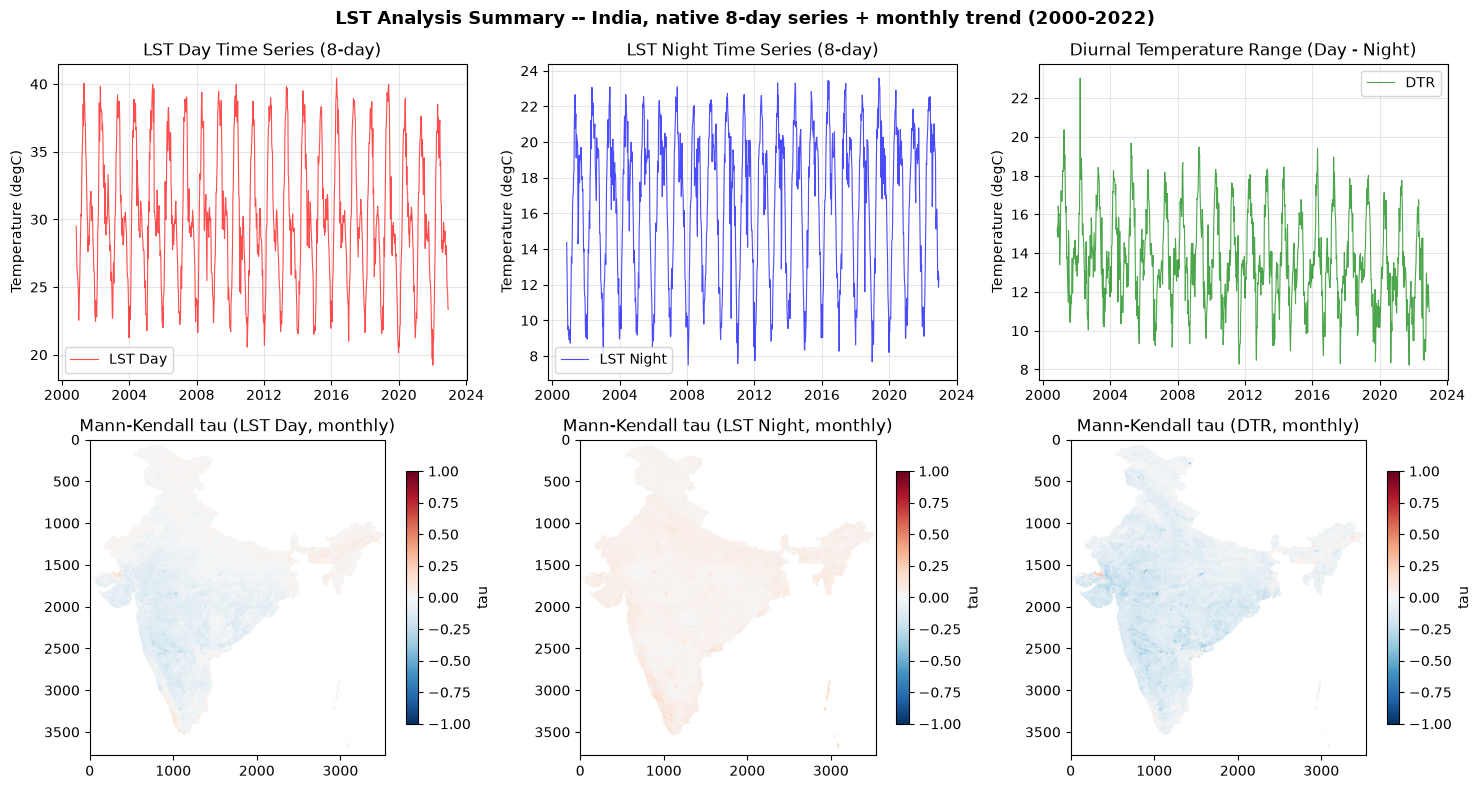

   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_Fire_Coincidence_Monthly.png


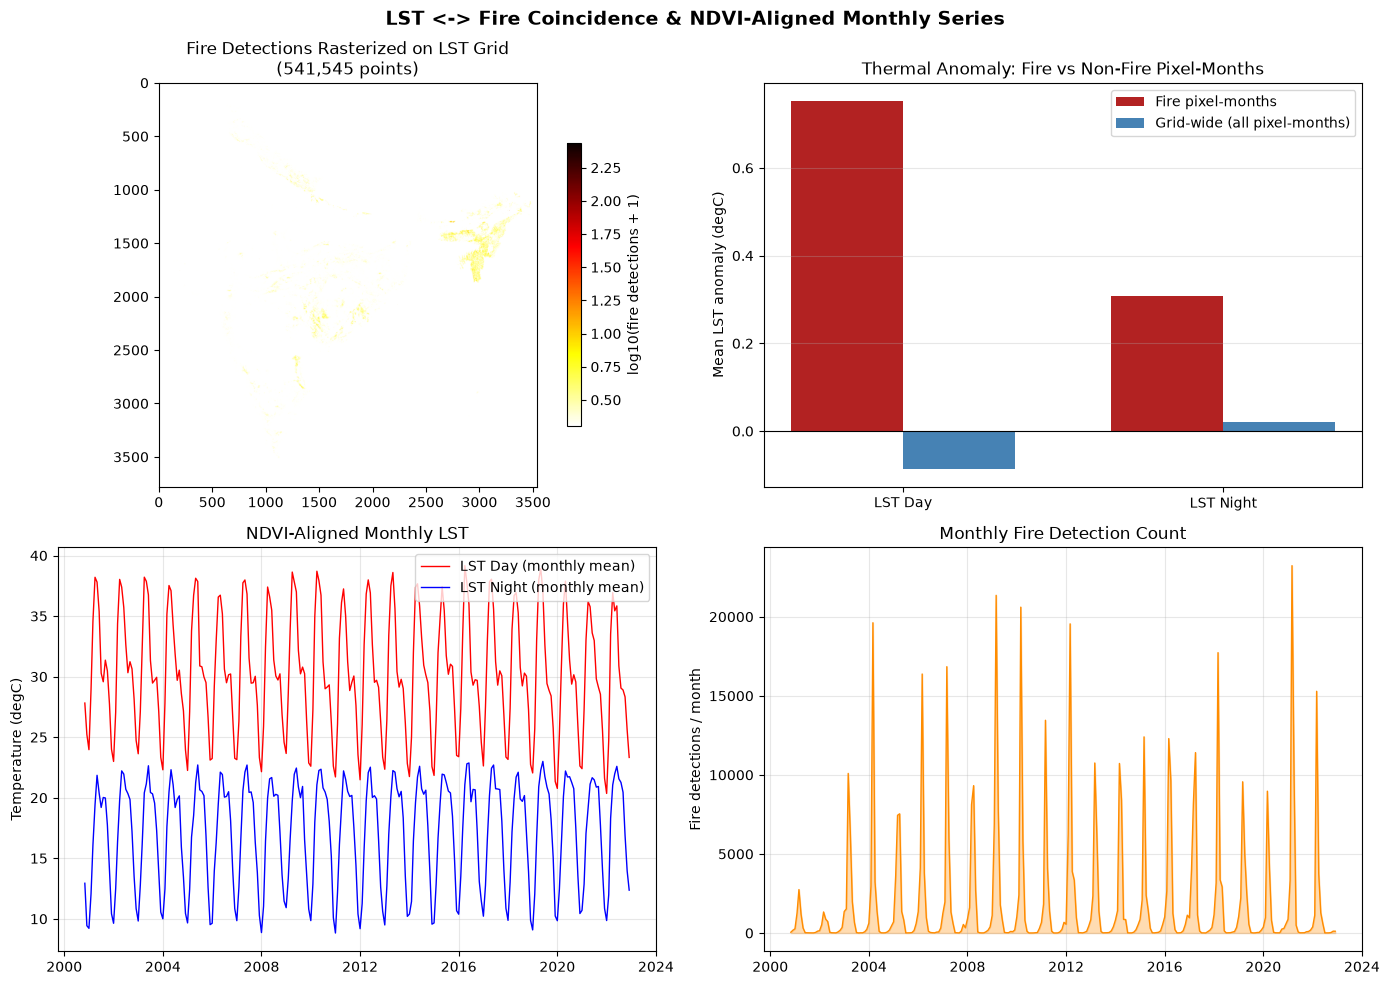

Visualizations complete


In [10]:
if len(df_study) > 0:
    print("Generating summary plots...")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("LST Analysis Summary -- India, native 8-day series + monthly trend (2000-2022)",
                 fontsize=13, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(df_dates['date'], df_dates['lst_day_mean'], 'r-', linewidth=0.8, alpha=0.7, label='LST Day')
    ax.set_ylabel('Temperature (degC)'); ax.set_title('LST Day Time Series (8-day)')
    ax.grid(True, alpha=0.3); ax.legend()

    ax = axes[0, 1]
    ax.plot(df_dates['date'], df_dates['lst_night_mean'], 'b-', linewidth=0.8, alpha=0.7, label='LST Night')
    ax.set_ylabel('Temperature (degC)'); ax.set_title('LST Night Time Series (8-day)')
    ax.grid(True, alpha=0.3); ax.legend()

    ax = axes[0, 2]
    ax.plot(df_dates['date'], df_dates['dtr_mean'], 'g-', linewidth=0.8, alpha=0.7, label='DTR')
    ax.set_ylabel('Temperature (degC)'); ax.set_title('Diurnal Temperature Range (Day - Night)')
    ax.grid(True, alpha=0.3); ax.legend()

    ax = axes[1, 0]
    im = ax.imshow(mk_day_monthly['tau'], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (LST Day, monthly)"); plt.colorbar(im, ax=ax, label='tau', shrink=0.8)

    ax = axes[1, 1]
    im = ax.imshow(mk_night_monthly['tau'], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (LST Night, monthly)"); plt.colorbar(im, ax=ax, label='tau', shrink=0.8)

    ax = axes[1, 2]
    im = ax.imshow(mk_dtr_monthly['tau'], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (DTR, monthly)"); plt.colorbar(im, ax=ax, label='tau', shrink=0.8)

    plt.tight_layout()
    outfile = os.path.join(OUTPUT_DIR, "LST_Summary_Analysis.png")
    plt.savefig(outfile, dpi=150, bbox_inches='tight')
    print(f"   Saved: {outfile}")
    plt.show()

    # --- Second figure: fire coincidence + NDVI-aligned monthly series ---
    fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle("LST <-> Fire Coincidence & NDVI-Aligned Monthly Series", fontsize=14, fontweight='bold')

    ax = axes2[0, 0]
    im = ax.imshow(np.where(fire_count_map > 0, np.log10(fire_count_map + 1), np.nan), cmap='hot_r')
    ax.set_title(f'Fire Detections Rasterized on LST Grid\n({len(df_fire):,} points)' if df_fire is not None
                 else 'Fire Detections Rasterized on LST Grid')
    plt.colorbar(im, ax=ax, label='log10(fire detections + 1)', shrink=0.7)

    ax = axes2[0, 1]
    labels = ['LST Day', 'LST Night']
    fire_vals = [fire_anom_day_mean, fire_anom_night_mean]
    all_vals = [all_anom_day_mean, all_anom_night_mean]
    x = np.arange(len(labels)); width = 0.35
    ax.bar(x - width/2, fire_vals, width, label='Fire pixel-months', color='firebrick')
    ax.bar(x + width/2, all_vals, width, label='Grid-wide (all pixel-months)', color='steelblue')
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('Mean LST anomaly (degC)')
    ax.set_title('Thermal Anomaly: Fire vs Non-Fire Pixel-Months')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y'); ax.axhline(0, color='black', linewidth=0.8)

    monthly_dates = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in monthly_year_month_list])
    monthly_day_mean_sp = np.nanmean(monthly_day, axis=(1, 2))
    monthly_night_mean_sp = np.nanmean(monthly_night, axis=(1, 2))
    monthly_fire_totals = fire_monthly_count.reshape(n_months, -1).sum(axis=1)

    ax = axes2[1, 0]
    ax.plot(monthly_dates, monthly_day_mean_sp, 'r-', linewidth=1, label='LST Day (monthly mean)')
    ax.plot(monthly_dates, monthly_night_mean_sp, 'b-', linewidth=1, label='LST Night (monthly mean)')
    ax.set_ylabel('Temperature (degC)'); ax.set_title('NDVI-Aligned Monthly LST')
    ax.grid(True, alpha=0.3); ax.legend()

    ax = axes2[1, 1]
    ax.plot(monthly_dates, monthly_fire_totals, color='darkorange', linewidth=1)
    ax.fill_between(monthly_dates, monthly_fire_totals, color='darkorange', alpha=0.3)
    ax.set_ylabel('Fire detections / month'); ax.set_title('Monthly Fire Detection Count')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    outfile2 = os.path.join(OUTPUT_DIR, "LST_Fire_Coincidence_Monthly.png")
    plt.savefig(outfile2, dpi=150, bbox_inches='tight')
    print(f"   Saved: {outfile2}")
    plt.show()

    print("Visualizations complete")

## 💾 Step 10 — Export Results

Saves CSV summaries (native 8-day + NDVI-aligned monthly), per-pixel GeoTIFFs on the 
native LST grid, and — the key alignment deliverable — the same monthly features 
reprojected onto the NDVI pipeline's exact grid via `rasterio.warp.reproject`, ready to 
stack pixel-for-pixel with the NDVI feature rasters.

In [11]:
if len(df_study) > 0:
    print("Exporting results...")

    # ---- 1. Native 8-day national time series ----
    df_export = df_dates[['date', 'year', 'month', 'lst_day_mean', 'lst_night_mean', 'dtr_mean']]
    csv_file = os.path.join(OUTPUT_DIR, "LST_temporal_statistics_8day.csv")
    df_export.to_csv(csv_file, index=False)
    print(f"   Saved: {csv_file}")

    # ---- 2. NDVI-aligned monthly statistics (join key: year, month) ----
    monthly_fire_totals = fire_monthly_count.reshape(n_months, -1).sum(axis=1)
    df_monthly_export = pd.DataFrame({
        'year': monthly_years_arr,
        'month': monthly_months_arr,
        'lst_day_mean': np.nanmean(monthly_day, axis=(1, 2)),
        'lst_night_mean': np.nanmean(monthly_night, axis=(1, 2)),
        'dtr_mean': np.nanmean(monthly_dtr, axis=(1, 2)),
        'lst_day_anom_mean': np.nanmean(monthly_anom_day, axis=(1, 2)),
        'lst_night_anom_mean': np.nanmean(monthly_anom_night, axis=(1, 2)),
        'dtr_anom_mean': np.nanmean(monthly_anom_dtr, axis=(1, 2)),
        'fire_detections': monthly_fire_totals,
    })
    monthly_csv = os.path.join(OUTPUT_DIR, "LST_monthly_statistics_NDVI_aligned.csv")
    df_monthly_export.to_csv(monthly_csv, index=False)
    print(f"   Saved: {monthly_csv}  <- join to the NDVI/fire monthly tables on (year, month)")

    # ---- 3. Trend summary (monthly resolution) ----
    trend_summary = pd.DataFrame({
        'metric': ['LST_Day_monthly', 'LST_Night_monthly', 'DTR_monthly'],
        'tau_mean': [
            float(np.nanmean(mk_day_monthly['tau'])),
            float(np.nanmean(mk_night_monthly['tau'])),
            float(np.nanmean(mk_dtr_monthly['tau'])),
        ],
        'tau_std': [
            float(np.nanstd(mk_day_monthly['tau'])),
            float(np.nanstd(mk_night_monthly['tau'])),
            float(np.nanstd(mk_dtr_monthly['tau'])),
        ],
        'n_increasing_pixels': [
            int((mk_day_monthly['trend_dir'] > 0).sum()),
            int((mk_night_monthly['trend_dir'] > 0).sum()),
            int((mk_dtr_monthly['trend_dir'] > 0).sum()),
        ],
        'n_decreasing_pixels': [
            int((mk_day_monthly['trend_dir'] < 0).sum()),
            int((mk_night_monthly['trend_dir'] < 0).sum()),
            int((mk_dtr_monthly['trend_dir'] < 0).sum()),
        ],
    })
    trend_file = os.path.join(OUTPUT_DIR, "LST_trend_summary.csv")
    trend_summary.to_csv(trend_file, index=False)
    print(f"   Saved: {trend_file}")

    # ---- 4. Per-pixel GeoTIFFs on the native LST grid ----
    def save_geotiff(array_2d, name, profile, out_dir):
        out_path = os.path.join(out_dir, f"{name}.tif")
        prof = profile.copy()
        prof.update(count=1, dtype='float32', nodata=np.nan, compress='lzw')
        with rasterio.open(out_path, 'w', **prof) as dst:
            dst.write(array_2d.astype(np.float32), 1)
        return out_path

    native_layers = {
        'LST_Day_climatology_annualmean': np.nanmean(clim_day_by_month, axis=0),
        'LST_Night_climatology_annualmean': np.nanmean(clim_night_by_month, axis=0),
        'LST_Day_anomaly_mean': np.nanmean(monthly_anom_day, axis=0),
        'LST_Night_anomaly_mean': np.nanmean(monthly_anom_night, axis=0),
        'DTR_anomaly_mean': np.nanmean(monthly_anom_dtr, axis=0),
        'DTR_mean': np.nanmean(monthly_dtr, axis=0),
        'MannKendall_tau_LST_Day_monthly': mk_day_monthly['tau'],
        'MannKendall_tau_LST_Night_monthly': mk_night_monthly['tau'],
        'MannKendall_tau_DTR_monthly': mk_dtr_monthly['tau'],
        'Fire_count_map': fire_count_map.astype(np.float32),
    }
    for name, arr in native_layers.items():
        p = save_geotiff(arr, name, profile_ref, OUTPUT_DIR)
        print(f"   Saved: {p}")

    # ---- 5. Reproject key monthly layers onto the NDVI pipeline's exact grid ----
    ndvi_ref_candidates = sorted(Path(NDVI_RAW_DIR).glob("*_NDVI_*.tif"))
    ndvi_ref_candidates = [f for f in ndvi_ref_candidates if 'reliability' not in f.name.lower()]

    if ndvi_ref_candidates:
        with rasterio.open(ndvi_ref_candidates[0]) as ndvi_ref:
            ndvi_transform = ndvi_ref.transform
            ndvi_crs = ndvi_ref.crs
            ndvi_shape = (ndvi_ref.height, ndvi_ref.width)
            ndvi_profile = ndvi_ref.profile.copy()

        def reproject_to_ndvi_grid(src_array):
            dst_array = np.full(ndvi_shape, np.nan, dtype=np.float32)
            reproject(
                source=np.ascontiguousarray(src_array.astype(np.float32)),
                destination=dst_array,
                src_transform=transform_ref, src_crs=crs_ref,
                dst_transform=ndvi_transform, dst_crs=ndvi_crs,
                src_nodata=np.nan, dst_nodata=np.nan,
                resampling=Resampling.average,
            )
            return dst_array

        aligned_layers = {
            'LST_Day_anomaly_mean_on_NDVI_grid': native_layers['LST_Day_anomaly_mean'],
            'LST_Night_anomaly_mean_on_NDVI_grid': native_layers['LST_Night_anomaly_mean'],
            'DTR_anomaly_mean_on_NDVI_grid': native_layers['DTR_anomaly_mean'],
            'MannKendall_tau_LST_Day_monthly_on_NDVI_grid': mk_day_monthly['tau'],
            'MannKendall_tau_LST_Night_monthly_on_NDVI_grid': mk_night_monthly['tau'],
            'Fire_count_map_on_NDVI_grid': fire_count_map.astype(np.float32),
        }
        for name, arr in aligned_layers.items():
            resampled = reproject_to_ndvi_grid(arr)
            p = save_geotiff(resampled, name, ndvi_profile, NDVI_ALIGNED_DIR)
            print(f"   Saved (NDVI grid): {p}")

        print(f"\n   NDVI-aligned outputs written to: {NDVI_ALIGNED_DIR}")
        print(f"   Shape now matches the NDVI pipeline's grid: {ndvi_shape}")
    else:
        print("   WARNING: No NDVI reference GeoTIFF found in NDVI_RAW_DIR -- skipped NDVI-grid reprojection")

    print(f"\nResults exported to {OUTPUT_DIR}")

Exporting results...
   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_temporal_statistics_8day.csv


   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_monthly_statistics_NDVI_aligned.csv  <- join to the NDVI/fire monthly tables on (year, month)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_trend_summary.csv


   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_Day_climatology_annualmean.tif


   Saved: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\LST_Night_climatology_annualmean.tif


...

   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs\LST_Night_anomaly_mean_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs\DTR_anomaly_mean_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs\MannKendall_tau_LST_Day_monthly_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs\MannKendall_tau_LST_Night_monthly_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs\Fire_count_map_on_NDVI_grid.tif

   NDVI-aligned outputs written to: D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs
   Shape now matches the NDVI pipeline's grid: (3641, 3504)

Results exported to D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs


## ✅ Pipeline Complete

**Outputs** (in `LST_Outputs/`):
- `LST_temporal_statistics_8day.csv` — national mean LST Day/Night/DTR per 8-day composite
- `LST_monthly_statistics_NDVI_aligned.csv` — monthly means, anomalies, and fire counts; 
  join key is `(year, month)`, matching the fire archive and the NDVI pipeline's own 
  `year_month_list`
- `LST_trend_summary.csv` — Mann-Kendall τ summary (monthly resolution)
- Per-pixel GeoTIFFs on the native LST grid (climatology, anomaly, τ, fire count)
- `NDVI_Aligned_GeoTIFFs/` — the same monthly features reprojected onto the NDVI grid

**Next step:** load the NDVI pipeline's own exported feature rasters alongside 
`NDVI_Aligned_GeoTIFFs/*.tif` (identical shape/transform/CRS) and 
`LST_monthly_statistics_NDVI_aligned.csv` alongside the NDVI monthly table, to build the 
joint multi-factor fire-risk feature matrix.